<a href="https://colab.research.google.com/github/Harnzt/Analisis-dan-Visualisasi-Data/blob/main/Tugas_5_AVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA, Feature Engineering, Clustering, dan Klasifikasi Ames Housing

Notebook ini dibuat untuk Google Colab berdasarkan dataset:
- `train.csv`
- `test.csv`
- `data_description.txt`
- `sample_submission.csv`

**Catatan penting:** target asli dataset adalah `SalePrice`, yaitu harga jual rumah, sehingga secara natural masalah ini adalah **regresi**.  
Namun karena tugas meminta **model klasifikasi**, notebook ini mengubah `SalePrice` menjadi kelas harga:
- `Murah`
- `Sedang`
- `Mahal`

Selain itu, bagian clustering digunakan untuk memahami **segmentasi properti/rumah**, bukan segmentasi pelanggan secara langsung, karena dataset tidak berisi identitas pelanggan.

In [30]:
# ============================================================
# 1. SETUP DAN LOAD DATA
# ============================================================

import os
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42

required_files = ["train.csv", "test.csv", "sample_submission.csv", "data_description.txt"]

if all(os.path.exists(os.path.join("/mnt/data", f)) for f in required_files):
    DATA_DIR = "/mnt/data"
else:
    DATA_DIR = "/content"

missing_files = [f for f in required_files if not os.path.exists(os.path.join(DATA_DIR, f))]

if missing_files:
    print("File berikut belum ada:", missing_files)
    print("Silakan upload train.csv, test.csv, sample_submission.csv, dan data_description.txt")
    try:
        from google.colab import files
        uploaded = files.upload()
        for name in uploaded.keys():
            shutil.move(name, os.path.join(DATA_DIR, name))
    except Exception as e:
        print("Upload otomatis hanya tersedia di Google Colab.")
        print("Jika menjalankan lokal, letakkan file di folder:", DATA_DIR)
        print("Error:", e)

train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head())

Train shape: (1460, 81)
Test shape : (1459, 80)
Sample submission shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. EDA: Memahami Struktur Dataset

Tujuan EDA:
1. Melihat ukuran data dan tipe variabel.
2. Mengecek missing value.
3. Melihat distribusi target `SalePrice`.
4. Melihat variabel yang berhubungan kuat dengan harga rumah.
5. Memahami pola harga berdasarkan kualitas, ukuran bangunan, dan lokasi.

In [31]:
# ============================================================
# 2.1 INFORMASI DASAR DATA
# ============================================================

print("Jumlah baris dan kolom train:", train.shape)
print("Jumlah baris dan kolom test :", test.shape)

print("Jumlah tipe data:")
display(train.dtypes.value_counts())

print("Statistik numerik:")
display(train.describe().T)

print("Statistik kategorikal:")
display(train.describe(include="object").T.head(20))

Jumlah baris dan kolom train: (1460, 81)
Jumlah baris dan kolom test : (1459, 80)
Jumlah tipe data:


,count
object,43
int64,35
float64,3


Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Statistik kategorikal:


,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


,Missing_Count,Missing_Percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


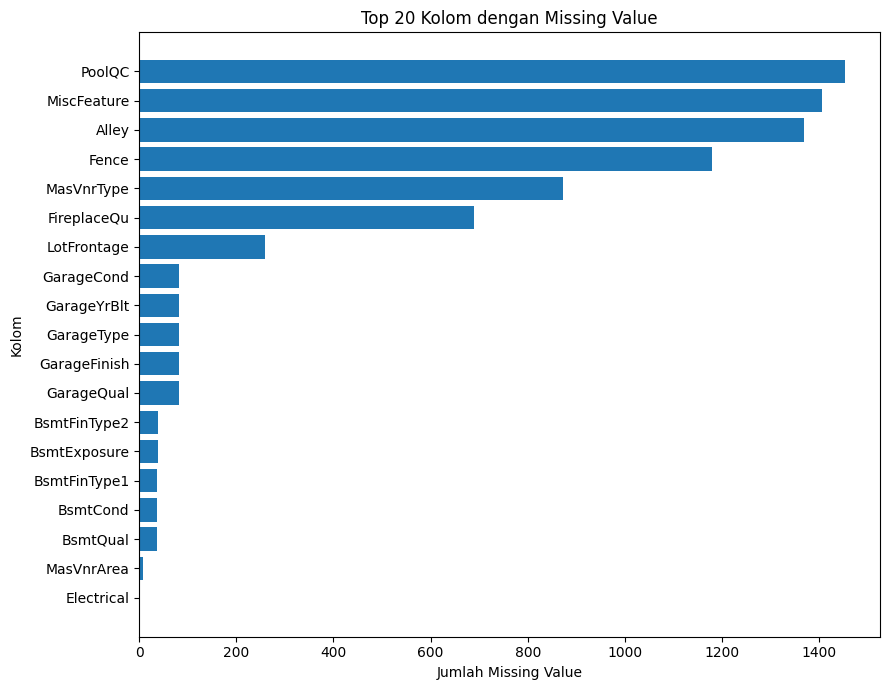

In [32]:
# ============================================================
# 2.2 MISSING VALUE
# ============================================================

missing = train.isna().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Count", ascending=False)

display(missing_df.head(25))

top_missing = missing_df[missing_df["Missing_Count"] > 0].head(20).sort_values("Missing_Count")

plt.figure(figsize=(9, 7))
plt.barh(top_missing.index, top_missing["Missing_Count"])
plt.title("Top 20 Kolom dengan Missing Value")
plt.xlabel("Jumlah Missing Value")
plt.ylabel("Kolom")
plt.tight_layout()
plt.show()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


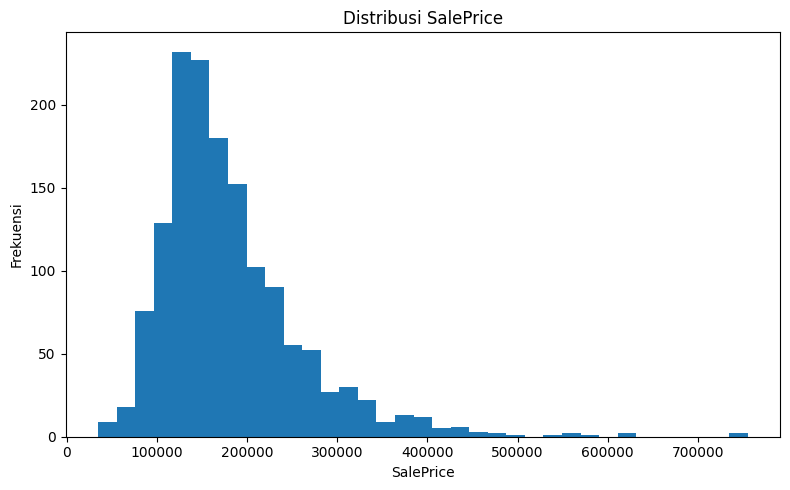

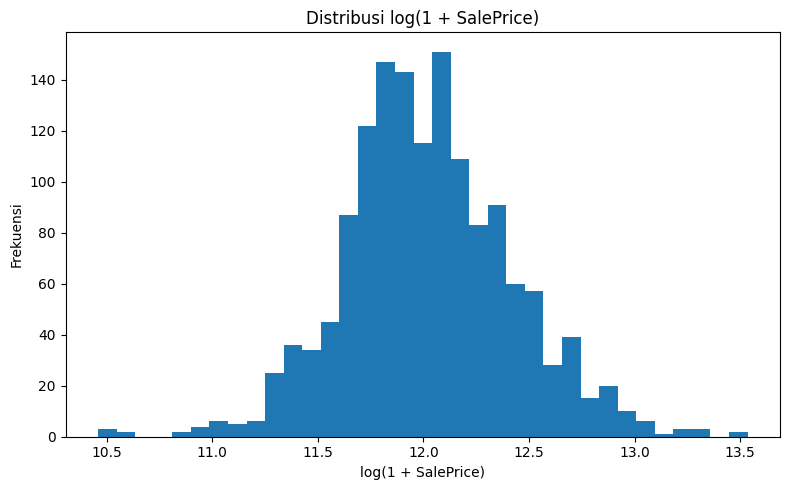

In [33]:
# ============================================================
# 2.3 DISTRIBUSI TARGET SALEPRICE
# ============================================================

display(train["SalePrice"].describe())

plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice"], bins=35)
plt.title("Distribusi SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train["SalePrice"]), bins=35)
plt.title("Distribusi log(1 + SalePrice)")
plt.xlabel("log(1 + SalePrice)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

,Correlation_with_SalePrice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


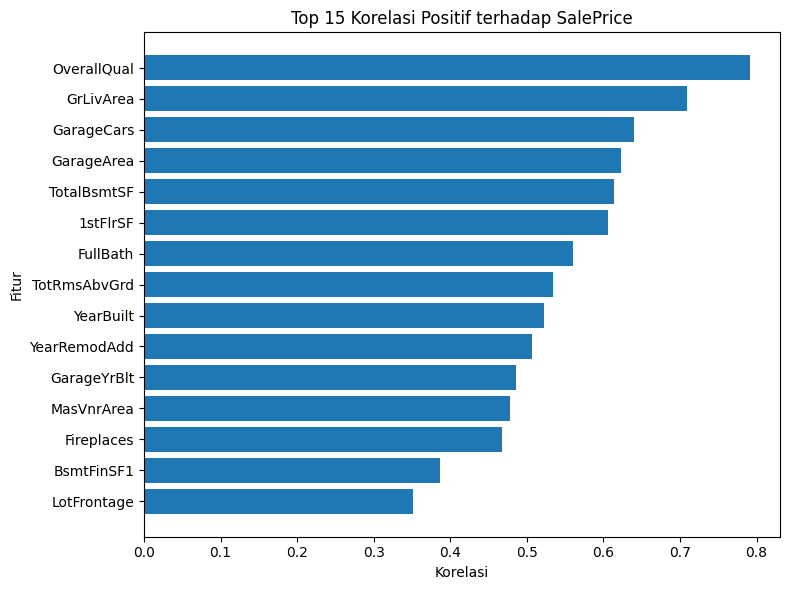

In [34]:
# ============================================================
# 2.4 KORELASI NUMERIK DENGAN SALEPRICE
# ============================================================

corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
top_corr = corr.drop("SalePrice").head(15)

display(top_corr.to_frame("Correlation_with_SalePrice"))

plt.figure(figsize=(8, 6))
plt.barh(top_corr.sort_values().index, top_corr.sort_values().values)
plt.title("Top 15 Korelasi Positif terhadap SalePrice")
plt.xlabel("Korelasi")
plt.ylabel("Fitur")
plt.tight_layout()
plt.show()

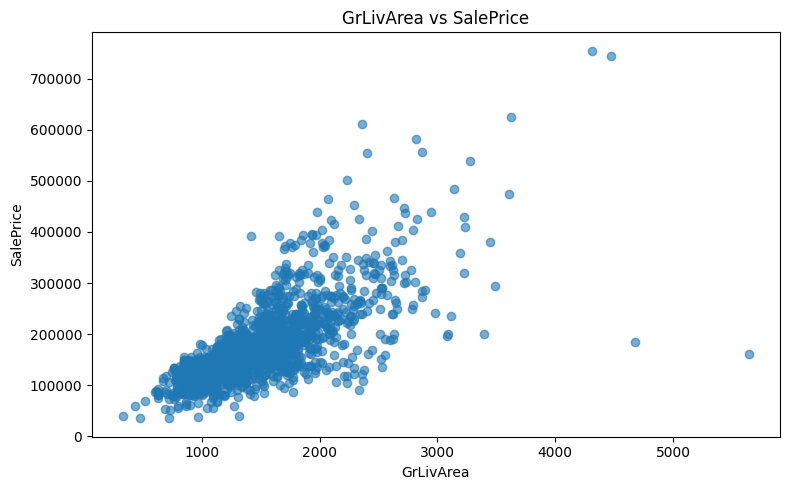

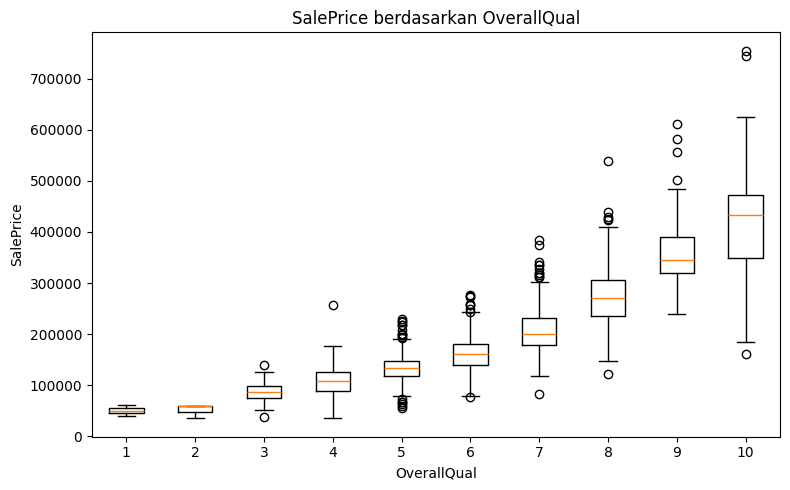

In [35]:
# ============================================================
# 2.5 HUBUNGAN FITUR PENTING DENGAN SALEPRICE
# ============================================================

plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.6)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
qual_groups = [train.loc[train["OverallQual"] == q, "SalePrice"] for q in sorted(train["OverallQual"].unique())]
plt.boxplot(qual_groups, labels=sorted(train["OverallQual"].unique()))
plt.title("SalePrice berdasarkan OverallQual")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

,Median_SalePrice
Neighborhood,
NridgHt,315000.0
NoRidge,301500.0
StoneBr,278000.0
Timber,228475.0
Somerst,225500.0
Veenker,218000.0
Crawfor,200624.0
ClearCr,200250.0
CollgCr,197200.0


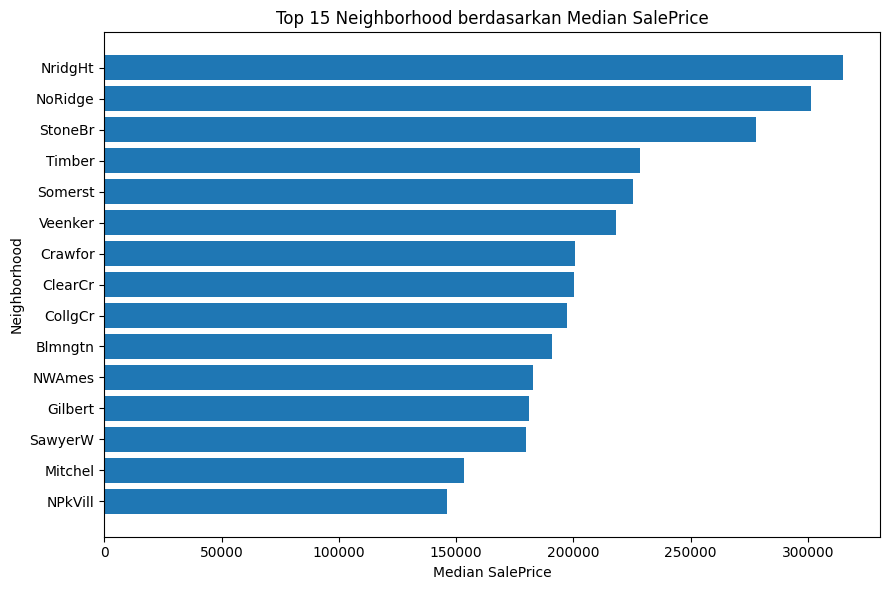

In [36]:
# ============================================================
# 2.6 ANALISIS KATEGORIKAL: NEIGHBORHOOD
# ============================================================

neigh_price = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).head(15)

display(neigh_price.to_frame("Median_SalePrice"))

plt.figure(figsize=(9, 6))
plt.barh(neigh_price.sort_values().index, neigh_price.sort_values().values)
plt.title("Top 15 Neighborhood berdasarkan Median SalePrice")
plt.xlabel("Median SalePrice")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# 2.7 OUTLIER SEDERHANA
# ============================================================

outlier_condition = (train["GrLivArea"] > 4500) & (train["SalePrice"] < 300000)
print("Jumlah outlier yang dihapus:", outlier_condition.sum())

train_clean = train.loc[~outlier_condition].copy()
print("Shape sebelum:", train.shape)
print("Shape sesudah:", train_clean.shape)

Jumlah outlier yang dihapus: 2
Shape sebelum: (1460, 81)
Shape sesudah: (1458, 81)


## 3. Feature Engineering

Feature engineering yang dilakukan:
1. Mengubah `MSSubClass` menjadi kategorikal karena sebenarnya berisi kode kelas bangunan.
2. Mengisi nilai kosong kategori tertentu sebagai `None`, misalnya tidak ada garasi, basement, kolam, atau pagar.
3. Mengubah beberapa fitur ordinal kualitas seperti `Ex`, `Gd`, `TA`, `Fa`, `Po` menjadi angka.
4. Membuat fitur baru: `TotalSF`, `TotalBathrooms`, `TotalPorchSF`, `HouseAge`, `RemodAge`, `GarageAge`, `IsRemodeled`, `HasGarage`, `HasBasement`, `HasFireplace`, `HasPool`, dan `QualityScore`.

In [38]:
# ============================================================
# 3. FEATURE ENGINEERING FUNCTION
# ============================================================

def add_features(df):
    df = df.copy()

    if "MSSubClass" in df.columns:
        df["MSSubClass"] = df["MSSubClass"].astype(str)

    none_cols = [
        "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
        "GarageType", "GarageFinish", "GarageQual", "GarageCond",
        "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
        "BsmtFinType2", "MasVnrType"
    ]
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    quality_map = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
    quality_cols = [
        "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
        "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"
    ]
    for col in quality_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map).fillna(0).astype(int)

    exposure_map = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "None": 0}
    if "BsmtExposure" in df.columns:
        df["BsmtExposure"] = df["BsmtExposure"].map(exposure_map).fillna(0).astype(int)

    finish_map = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "None": 0}
    for col in ["BsmtFinType1", "BsmtFinType2"]:
        if col in df.columns:
            df[col] = df[col].map(finish_map).fillna(0).astype(int)

    garage_finish_map = {"Fin": 3, "RFn": 2, "Unf": 1, "None": 0}
    if "GarageFinish" in df.columns:
        df["GarageFinish"] = df["GarageFinish"].map(garage_finish_map).fillna(0).astype(int)

    def col0(name):
        return df[name].fillna(0) if name in df.columns else 0

    df["TotalSF"] = col0("TotalBsmtSF") + col0("1stFlrSF") + col0("2ndFlrSF")
    df["TotalBathrooms"] = col0("FullBath") + 0.5 * col0("HalfBath") + col0("BsmtFullBath") + 0.5 * col0("BsmtHalfBath")
    df["TotalPorchSF"] = col0("OpenPorchSF") + col0("EnclosedPorch") + col0("3SsnPorch") + col0("ScreenPorch")
    df["HouseAge"] = col0("YrSold") - col0("YearBuilt")
    df["RemodAge"] = col0("YrSold") - col0("YearRemodAdd")

    if "GarageYrBlt" in df.columns:
        df["GarageAge"] = np.where(df["GarageYrBlt"].notna(), col0("YrSold") - df["GarageYrBlt"].fillna(0), 0)
    else:
        df["GarageAge"] = 0

    for col in ["HouseAge", "RemodAge", "GarageAge"]:
        df[col] = pd.Series(df[col]).clip(lower=0)

    df["IsRemodeled"] = np.where(col0("YearBuilt") != col0("YearRemodAdd"), 1, 0)
    df["HasGarage"] = np.where(col0("GarageArea") > 0, 1, 0)
    df["HasBasement"] = np.where(col0("TotalBsmtSF") > 0, 1, 0)
    df["HasFireplace"] = np.where(col0("Fireplaces") > 0, 1, 0)
    df["HasPool"] = np.where(col0("PoolArea") > 0, 1, 0)

    if "OverallQual" in df.columns and "OverallCond" in df.columns:
        df["QualityScore"] = df["OverallQual"] * df["OverallCond"]

    return df

train_fe = add_features(train_clean)
test_fe = add_features(test)

print("Train setelah feature engineering:", train_fe.shape)
print("Test setelah feature engineering :", test_fe.shape)

display(train_fe.head())

Train setelah feature engineering: (1458, 93)
Test setelah feature engineering : (1459, 92)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,TotalPorchSF,HouseAge,RemodAge,GarageAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,QualityScore
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,61,5,5,5.0,0,1,1,0,0,35
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,0,31,31,31.0,0,1,1,1,0,48
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,42,7,6,7.0,1,1,1,1,0,35
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,307,91,36,8.0,1,1,1,1,0,35
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,84,8,8,8.0,0,1,1,1,0,40


## 4. Membuat Target Klasifikasi

Karena target asli berupa angka kontinu (`SalePrice`), maka dibuat kategori harga menggunakan quantile:
- 33% terbawah = `Murah`
- 33% tengah = `Sedang`
- 33% atas = `Mahal`

Cara ini membuat jumlah data tiap kelas relatif seimbang.

Batas kategori harga berdasarkan quantile:


,SalePrice
0.000000,34900.000000
0.333333,139566.666667
0.666667,190000.000000
1.000000,755000.000000


Distribusi kelas:


,Count
PriceClass,
Murah,486
Sedang,489
Mahal,483


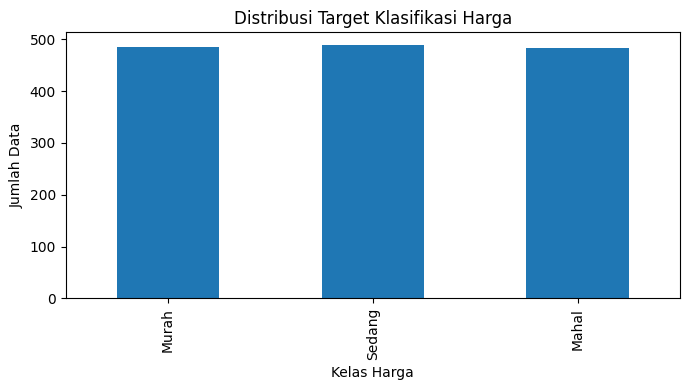

In [39]:
# ============================================================
# 4. MEMBUAT LABEL KLASIFIKASI HARGA
# ============================================================

price_order = ["Murah", "Sedang", "Mahal"]
label_map = {"Murah": 0, "Sedang": 1, "Mahal": 2}
inverse_label_map = {v: k for k, v in label_map.items()}

train_fe["PriceClass"] = pd.qcut(train_fe["SalePrice"], q=3, labels=price_order)
train_fe["PriceClassEncoded"] = train_fe["PriceClass"].map(label_map).astype(int)

print("Batas kategori harga berdasarkan quantile:")
display(train_fe["SalePrice"].quantile([0, 1/3, 2/3, 1]).to_frame("SalePrice"))

print("Distribusi kelas:")
display(train_fe["PriceClass"].value_counts().loc[price_order].to_frame("Count"))

plt.figure(figsize=(7, 4))
train_fe["PriceClass"].value_counts().loc[price_order].plot(kind="bar")
plt.title("Distribusi Target Klasifikasi Harga")
plt.xlabel("Kelas Harga")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

## 5. Preprocessing Pipeline

Preprocessing:
- Numerik: imputasi median dan scaling.
- Kategorikal: imputasi modus dan One-Hot Encoding.
- `Id`, `SalePrice`, `PriceClass`, dan `PriceClassEncoded` tidak digunakan sebagai fitur training.

In [40]:
# ============================================================
# 5. PREPROCESSING
# ============================================================

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def build_preprocessor(X):
    categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    return preprocessor, numeric_cols, categorical_cols


drop_cols = ["Id", "SalePrice", "PriceClass", "PriceClassEncoded"]
feature_cols = [c for c in train_fe.columns if c not in drop_cols]

X = train_fe[feature_cols].copy()
y = train_fe["PriceClassEncoded"].copy()

preprocessor, numeric_cols, categorical_cols = build_preprocessor(X)

print("Jumlah fitur sebelum encoding:", X.shape[1])
print("Jumlah fitur numerik:", len(numeric_cols))
print("Jumlah fitur kategorikal:", len(categorical_cols))

Jumlah fitur sebelum encoding: 91
Jumlah fitur numerik: 61
Jumlah fitur kategorikal: 30


## 6. Dimension Reduction

Setelah One-Hot Encoding, jumlah fitur bisa bertambah besar. Untuk reduksi dimensi digunakan `TruncatedSVD`, yaitu teknik yang cocok untuk data hasil One-Hot Encoding yang bisa berbentuk sparse matrix.

Dimensi sebelum reduction: (1458, 268)
Dimensi setelah reduction: (1458, 40)
Total explained variance ratio: 88.87%


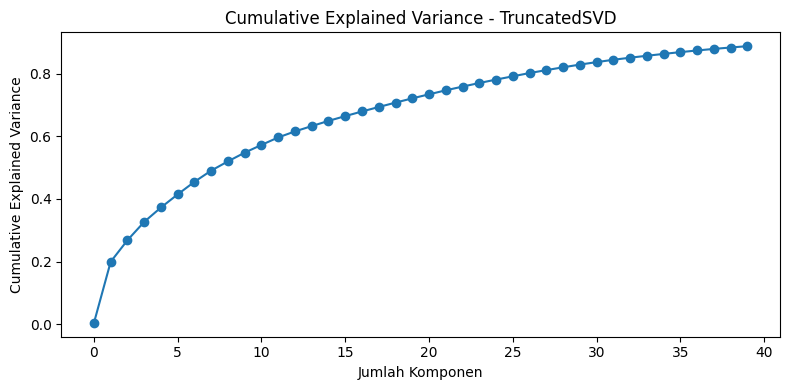

In [41]:
# ============================================================
# 6. DIMENSION REDUCTION DENGAN TRUNCATED SVD
# ============================================================

preprocessor_dr, _, _ = build_preprocessor(X)
X_prepared = preprocessor_dr.fit_transform(X)

print("Dimensi sebelum reduction:", X_prepared.shape)

n_components = min(40, X_prepared.shape[1] - 1, X_prepared.shape[0] - 1)
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_reduced = svd.fit_transform(X_prepared)

explained = svd.explained_variance_ratio_.sum()

print("Dimensi setelah reduction:", X_reduced.shape)
print(f"Total explained variance ratio: {explained:.2%}")

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker="o")
plt.title("Cumulative Explained Variance - TruncatedSVD")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

## 7. Clustering untuk Segmentasi

Clustering dilakukan menggunakan `KMeans`. Jumlah cluster dipilih berdasarkan **Silhouette Score**. Interpretasi cluster dilihat dari rata-rata harga, luas rumah, kualitas rumah, umur rumah, dan fitur penting lainnya.

,k,Silhouette_Score,Inertia
0,2,0.163498,77098.412011
1,3,0.166341,72721.924566
2,4,0.167519,67692.533313
3,5,0.182031,64090.629962
4,6,0.109402,62384.194083
5,7,0.116788,58530.705403


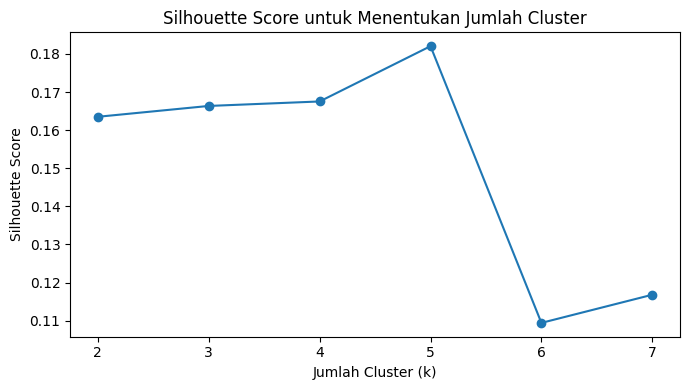

Jumlah cluster terbaik berdasarkan Silhouette Score: 5


,Jumlah_Data
Cluster,
0,74
1,713
2,628
3,6
4,37


In [42]:
# ============================================================
# 7. CLUSTERING DENGAN KMEANS
# ============================================================

k_values = range(2, 8)
silhouette_scores = []
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    clusters = kmeans.fit_predict(X_reduced)
    silhouette_scores.append(silhouette_score(X_reduced, clusters))
    inertias.append(kmeans.inertia_)

cluster_eval = pd.DataFrame({
    "k": list(k_values),
    "Silhouette_Score": silhouette_scores,
    "Inertia": inertias
})

display(cluster_eval)

plt.figure(figsize=(7, 4))
plt.plot(cluster_eval["k"], cluster_eval["Silhouette_Score"], marker="o")
plt.title("Silhouette Score untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = int(cluster_eval.loc[cluster_eval["Silhouette_Score"].idxmax(), "k"])
print("Jumlah cluster terbaik berdasarkan Silhouette Score:", best_k)

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
train_fe["Cluster"] = kmeans_final.fit_predict(X_reduced)

display(train_fe["Cluster"].value_counts().sort_index().to_frame("Jumlah_Data"))

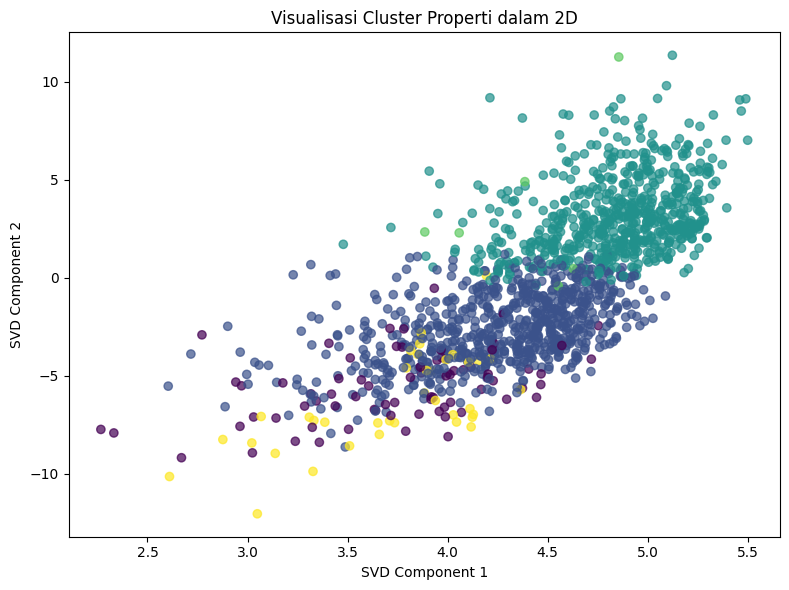

In [43]:
# ============================================================
# 7.1 VISUALISASI CLUSTER 2D
# ============================================================

svd_2d = TruncatedSVD(n_components=2, random_state=RANDOM_STATE)
X_2d = svd_2d.fit_transform(X_prepared)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=train_fe["Cluster"], alpha=0.7)
plt.title("Visualisasi Cluster Properti dalam 2D")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.tight_layout()
plt.show()

In [44]:
# ============================================================
# 7.2 RINGKASAN KARAKTERISTIK CLUSTER
# ============================================================

cluster_summary = train_fe.groupby("Cluster").agg(
    Jumlah_Data=("Id", "count"),
    Rata2_SalePrice=("SalePrice", "mean"),
    Median_SalePrice=("SalePrice", "median"),
    Rata2_OverallQual=("OverallQual", "mean"),
    Rata2_GrLivArea=("GrLivArea", "mean"),
    Rata2_TotalSF=("TotalSF", "mean"),
    Rata2_HouseAge=("HouseAge", "mean"),
    Rata2_GarageCars=("GarageCars", "mean"),
    Rata2_TotalBathrooms=("TotalBathrooms", "mean")
).round(2)

display(cluster_summary)

print("Interpretasi umum:")
print("- Cluster dengan rata-rata SalePrice, OverallQual, TotalSF, dan GarageCars tinggi dapat dianggap sebagai segmen properti premium.")
print("- Cluster dengan SalePrice dan luas bangunan rendah dapat dianggap sebagai segmen ekonomis.")
print("- Cluster tengah biasanya merepresentasikan properti standar/menengah.")

,Jumlah_Data,Rata2_SalePrice,Median_SalePrice,Rata2_OverallQual,Rata2_GrLivArea,Rata2_TotalSF,Rata2_HouseAge,Rata2_GarageCars,Rata2_TotalBathrooms
Cluster,,,,,,,,,
0,74,105576.35,102600.0,4.68,1198.22,2000.31,65.39,0.00,1.76
1,713,139527.65,137500.0,5.35,1301.40,2239.74,55.78,1.52,1.79
2,628,240028.99,219750.0,7.21,1788.20,3046.38,10.53,2.27,2.77
3,6,309495.00,242500.0,7.17,2500.00,3764.83,38.33,2.00,3.17
4,37,105652.89,101800.0,4.30,1289.32,1287.89,51.49,1.41,1.62


Interpretasi umum:
- Cluster dengan rata-rata SalePrice, OverallQual, TotalSF, dan GarageCars tinggi dapat dianggap sebagai segmen properti premium.
- Cluster dengan SalePrice dan luas bangunan rendah dapat dianggap sebagai segmen ekonomis.
- Cluster tengah biasanya merepresentasikan properti standar/menengah.


## 8. Model Klasifikasi

Model yang digunakan:
1. **Random Forest Classifier**
2. **XGBoost Classifier**

Evaluasi menggunakan Accuracy, F1 Weighted, Classification Report, dan Confusion Matrix.

In [45]:
# ============================================================
# 8. TRAIN-VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train distribution:")
display(y_train.map(inverse_label_map).value_counts().loc[price_order].to_frame("Count"))

X_train: (1166, 91)
X_val  : (292, 91)
y_train distribution:


,Count
PriceClassEncoded,
Murah,389
Sedang,391
Mahal,386


In [46]:
# ============================================================
# 8.1 HELPER EVALUASI MODEL
# ============================================================

def evaluate_classifier(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average="weighted")

    print(f"=== {model_name} ===")
    print("Accuracy   :", round(acc, 4))
    print("F1 Weighted:", round(f1, 4))
    print("Classification Report:")
    print(classification_report(
        y_val, y_pred,
        labels=[0, 1, 2],
        target_names=price_order
    ))

    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=price_order)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "F1_Weighted": f1
    }

=== Random Forest Classifier ===
Accuracy   : 0.839
F1 Weighted: 0.8399
Classification Report:
              precision    recall  f1-score   support

       Murah       0.84      0.84      0.84        97
      Sedang       0.75      0.79      0.77        98
       Mahal       0.93      0.90      0.91        97

    accuracy                           0.84       292
   macro avg       0.84      0.84      0.84       292
weighted avg       0.84      0.84      0.84       292



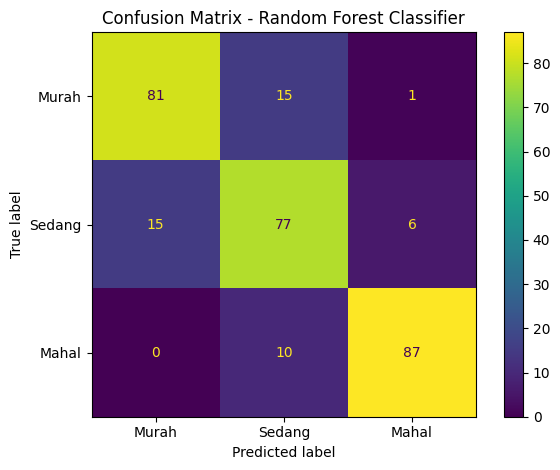

In [47]:
# ============================================================
# 8.2 RANDOM FOREST CLASSIFIER
# ============================================================

rf_preprocessor, _, _ = build_preprocessor(X)

rf_model = Pipeline(steps=[
    ("preprocess", rf_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_result = evaluate_classifier(
    rf_model, X_val, y_val,
    "Random Forest Classifier"
)

=== XGBoost Classifier ===
Accuracy   : 0.8425
F1 Weighted: 0.8428
Classification Report:
              precision    recall  f1-score   support

       Murah       0.87      0.84      0.85        97
      Sedang       0.76      0.79      0.77        98
       Mahal       0.90      0.91      0.90        97

    accuracy                           0.84       292
   macro avg       0.84      0.84      0.84       292
weighted avg       0.84      0.84      0.84       292



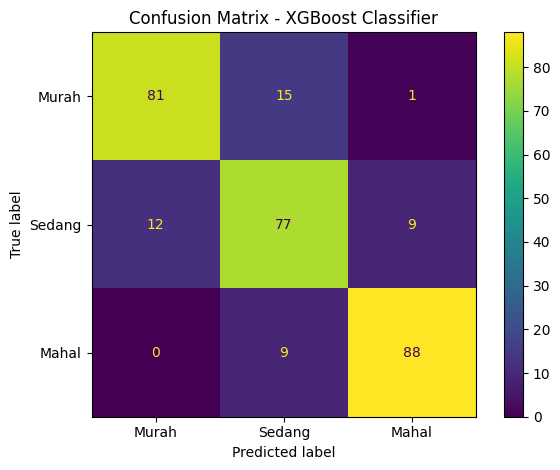

In [48]:
# ============================================================
# 8.3 XGBOOST CLASSIFIER
# ============================================================

try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBClassifier

xgb_preprocessor, _, _ = build_preprocessor(X)

xgb_model = Pipeline(steps=[
    ("preprocess", xgb_preprocessor),
    ("model", XGBClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=2,
        tree_method="hist",
        verbosity=0
    ))
])

xgb_model.fit(X_train, y_train)

xgb_result = evaluate_classifier(
    xgb_model, X_val, y_val,
    "XGBoost Classifier"
)

In [49]:
# ============================================================
# 8.4 PERBANDINGAN MODEL
# ============================================================

results_df = pd.DataFrame([rf_result, xgb_result]).sort_values(
    "F1_Weighted", ascending=False
)

display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("Model terbaik berdasarkan F1 Weighted:", best_model_name)

,Model,Accuracy,F1_Weighted
1,XGBoost Classifier,0.842466,0.842785
0,Random Forest Classifier,0.839041,0.839884


Model terbaik berdasarkan F1 Weighted: XGBoost Classifier


## 9. Feature Importance

Feature importance membantu memahami faktor apa saja yang paling berpengaruh dalam klasifikasi harga.

,Feature,Importance
49,num__TotalSF,0.080226
22,num__GrLivArea,0.056242
2,num__OverallQual,0.047514
36,num__GarageArea,0.037828
17,num__TotalBsmtSF,0.036433
19,num__1stFlrSF,0.033265
4,num__YearBuilt,0.030422
52,num__HouseAge,0.029575
60,num__QualityScore,0.022564
33,num__GarageYrBlt,0.022482


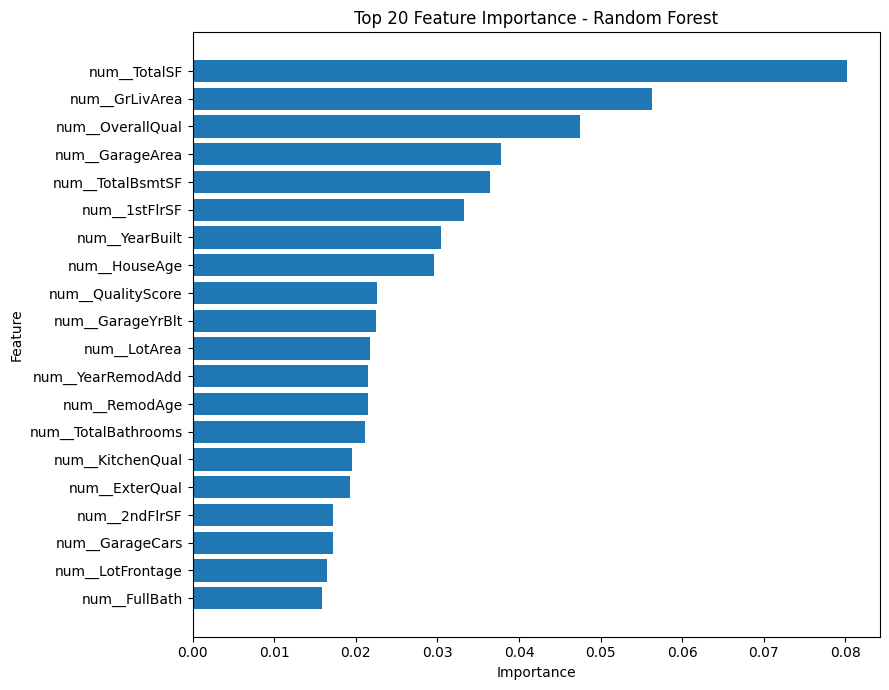

In [50]:
# ============================================================
# 9. FEATURE IMPORTANCE RANDOM FOREST
# ============================================================

def get_feature_names_from_pipeline(pipeline):
    preprocessor_fitted = pipeline.named_steps["preprocess"]
    try:
        return preprocessor_fitted.get_feature_names_out()
    except Exception:
        return [f"feature_{i}" for i in range(len(pipeline.named_steps["model"].feature_importances_))]

feature_names_rf = get_feature_names_from_pipeline(rf_model)
rf_importance = pd.DataFrame({
    "Feature": feature_names_rf,
    "Importance": rf_model.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

display(rf_importance.head(20))

plt.figure(figsize=(9, 7))
top_imp = rf_importance.head(20).sort_values("Importance")
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.title("Top 20 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

,Feature,Importance
2,num__OverallQual,0.101075
49,num__TotalSF,0.049383
35,num__GarageCars,0.033823
34,num__GarageFinish,0.028457
29,num__KitchenQual,0.026674
80,cat__MSZoning_RM,0.026615
7,num__ExterQual,0.024133
235,cat__GarageType_Detchd,0.020483
5,num__YearRemodAdd,0.018642
4,num__YearBuilt,0.018160


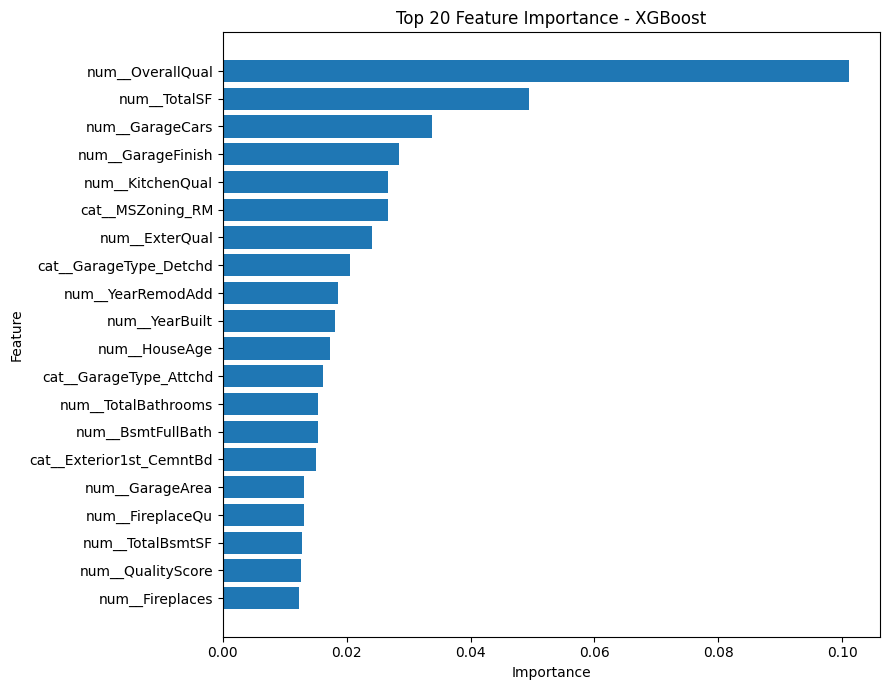

In [51]:
# ============================================================
# 9.1 FEATURE IMPORTANCE XGBOOST
# ============================================================

feature_names_xgb = get_feature_names_from_pipeline(xgb_model)
xgb_importance = pd.DataFrame({
    "Feature": feature_names_xgb,
    "Importance": xgb_model.named_steps["model"].feature_importances_
}).sort_values("Importance", ascending=False)

display(xgb_importance.head(20))

plt.figure(figsize=(9, 7))
top_imp_xgb = xgb_importance.head(20).sort_values("Importance")
plt.barh(top_imp_xgb["Feature"], top_imp_xgb["Importance"])
plt.title("Top 20 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Prediksi Kelas Harga pada `test.csv`

Karena `test.csv` tidak memiliki `SalePrice`, maka hasil prediksi berupa kelas harga:
- `Murah`
- `Sedang`
- `Mahal`

File output yang dibuat: `classification_predictions.csv`.

In [53]:
# ============================================================
# 10. PREDIKSI DATA TEST
# ============================================================

test_X = test_fe[feature_cols].copy()

best_model = rf_model if best_model_name == "Random Forest Classifier" else xgb_model

test_pred_encoded = best_model.predict(test_X)
test_pred_label = pd.Series(test_pred_encoded).map(inverse_label_map)

prediction_df = pd.DataFrame({
    "Id": test["Id"],
    "PredictedPriceClass": test_pred_label
})

display(prediction_df.head())

prediction_df.to_csv("classification_predictions.csv", index=False)
print("File classification_predictions.csv berhasil dibuat.")

try:
    from google.colab import files
    files.download("classification_predictions.csv")
except Exception:
    print("Download otomatis hanya tersedia di Google Colab.")

models = {
    "Random Forest Classifier": rf_model,
    "XGBoost Classifier": xgb_model
}

best_model = models[best_model_name]

print("Model yang digunakan untuk prediksi data test:", best_model_name)

,Id,PredictedPriceClass
0,1461,Murah
1,1462,Sedang
2,1463,Sedang
3,1464,Sedang
4,1465,Sedang


File classification_predictions.csv berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model yang digunakan untuk prediksi data test: XGBoost Classifier


## 11. Kesimpulan

Dari notebook ini:
1. Dataset Ames Housing dianalisis menggunakan EDA untuk memahami missing value, distribusi harga, korelasi, dan pola harga berdasarkan kualitas/lokasi.
2. Feature engineering dilakukan dengan membuat fitur gabungan seperti `TotalSF`, `TotalBathrooms`, `HouseAge`, dan indikator fasilitas.
3. Dimension reduction menggunakan `TruncatedSVD` karena hasil One-Hot Encoding dapat membuat dimensi fitur meningkat.
4. Clustering menggunakan KMeans untuk membuat segmentasi properti berdasarkan karakteristik rumah.
5. Model klasifikasi dibuat dengan Random Forest dan XGBoost untuk mengelompokkan harga rumah ke kelas `Murah`, `Sedang`, dan `Mahal`.

Jika tujuan akhirnya adalah memprediksi harga dalam bentuk angka dolar, maka pendekatan yang lebih tepat adalah model **regresi**, misalnya RandomForestRegressor, XGBRegressor, Linear Regression, atau Gradient Boosting Regressor.